**Project Name:** Credit Card Fraud Detection Using CTGAN and XGBoost

**Contribution:** Individual

**Project Summary:**

This project develops a Credit Card Fraud Detection System using CTGAN and XGBoost. CTGAN is used to generate synthetic fraud transactions to solve the class imbalance problem. Important features are selected to reduce deployment complexity and allow prediction using only 5 input variables. The model is evaluated using ROC-AUC, Confusion Matrix, PCA visualization. Finally, the system is deployed using Streamlit as a user-friendly web application.

**Problem Statement:**

Credit card fraud detection is challenging because fraud transactions are very few compared to genuine transactions, creating a highly imbalanced dataset. Traditional machine learning models often fail to detect fraud accurately due to this imbalance. This project aims to develop an efficient fraud detection system using CTGAN and XGBoost to improve fraud detection performance by generating synthetic fraud samples and reducing model complexity using feature selection.

**1.Data Understanding**

Install Libraries

In [ ]:
!pip install sdv xgboost

Import Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.decomposition import PCA

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

import joblib

Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

Mounted at /content/drive


**2.Understanding Variables**

In [ ]:
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print('\nDataset Info:')
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [ ]:
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**3.Data Preprocessing**

In [ ]:
print('\nMissing values in each column:')
display(df.isnull().sum())


Missing values in each column:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
print("\nDropping duplicates\n")
df = df.drop_duplicates()
df.shape


Dropping duplicates



(283726, 31)

Visualize Class Distribution

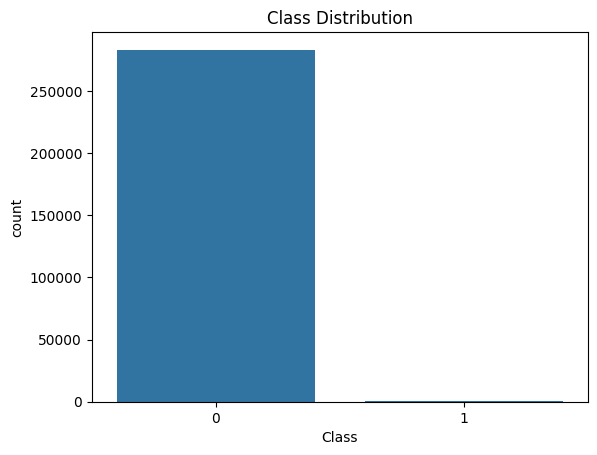

In [ ]:
sns.countplot(x='Class', data=df)

plt.title("Class Distribution")

plt.show()

*   Severe class imbalance: very few fraudulent transactions (Class 1) compared to non-fraudulent (Class 0).
*   This imbalance highlights the necessity of data augmentation techniques (like CTGAN) for a balanced dataset and effective model training.

Feature Scaling

In [ ]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

df['Time'] = scaler.fit_transform(df[['Time']])

Feature Selection

In [ ]:
temp_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

temp_model.fit(
    df.drop('Class', axis=1),
    df['Class']
)

importance = pd.Series(
    temp_model.feature_importances_,
    index=df.drop('Class', axis=1).columns
)

top_features = importance.sort_values(
    ascending=False
).head(5).index

print("Top Features:")
print(top_features)

# Keep only top features
df = df[list(top_features) + ['Class']]

Top Features:
Index(['V17', 'V14', 'V12', 'V10', 'V16'], dtype='object')


Seperate Fraud Data

In [ ]:
fraud_df = df[df['Class'] == 1]

Train CTGAN

In [ ]:
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(data=fraud_df)

ctgan = CTGANSynthesizer(metadata)

ctgan.fit(fraud_df)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Generate Synthetic Fraud Data

In [ ]:
synthetic_fraud = ctgan.sample(num_rows=3000)

print(synthetic_fraud.head())

        V17        V14       V12        V10       V16  Class
0  4.357160  -2.885714 -1.964489   2.654232 -4.786266      1
1 -0.000256  -4.926656 -7.161999 -10.197636 -3.127175      1
2 -2.093772 -12.477660 -7.535260   0.137880 -3.858070      1
3  6.739384   0.026314 -5.976198  -6.543014 -5.880433      1
4 -2.629811  -0.359993 -0.437629  -1.857307 -6.276047      1


Combine Original and Synthetic Data

In [ ]:
augmented_data = pd.concat(
    [df, synthetic_fraud],
    ignore_index=True
)

New Class Distribution

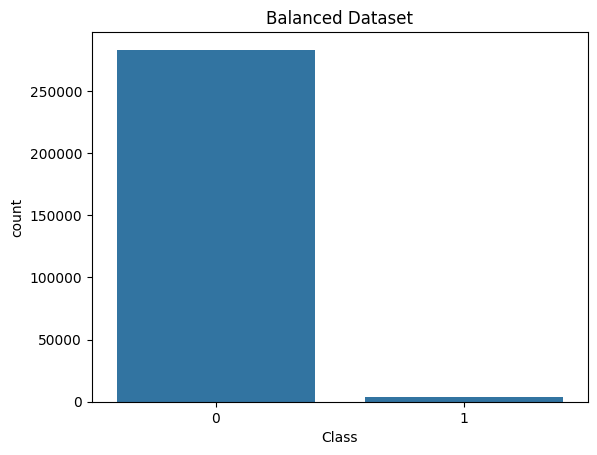

In [ ]:
sns.countplot(
    x='Class',
    data=augmented_data
)

plt.title("Balanced Dataset")

plt.show()

*   Plot confirms a more balanced distribution between fraudulent and non-fraudulent classes after CTGAN synthetic data generation.
*   Increased Class 1 samples aim to help the model learn fraud patterns more effectively, overcoming the original imbalance.

Features and Labels

In [ ]:
X = augmented_data.drop('Class', axis=1)

y = augmented_data['Class']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train XGBoost Model

In [ ]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:12:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Predictions

In [ ]:
y_pred = xgb.predict(X_test)

y_prob = xgb.predict_proba(X_test)[:,1]

Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.93      0.95       695

    accuracy                           1.00     57346
   macro avg       0.98      0.97      0.97     57346
weighted avg       1.00      1.00      1.00     57346



Confusion Matrix

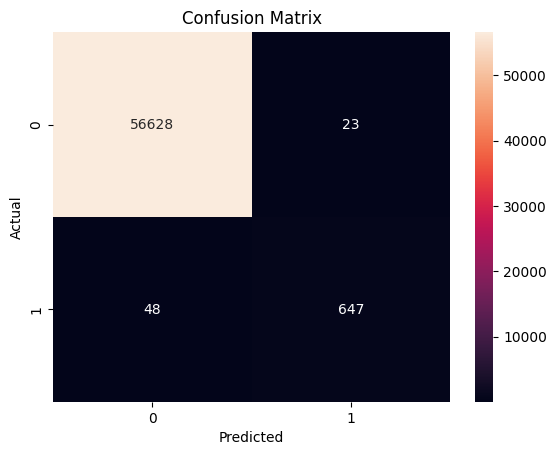

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

*   Correctly identified non-fraudulent transactions (True Negatives - TN).
*   Non-fraudulent transactions incorrectly flagged as fraudulent (False Positives - FP).
*   Crucial error: fraudulent transactions missed by the model (False Negatives - FN).
*   Correctly identified fraudulent transactions (True Positives - TP).
*   Analysis helps understand errors and biases, focusing on minimizing False Negatives in fraud detection.

ROC-AUC Score

In [ ]:
roc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9925416239707745


ROC Curve

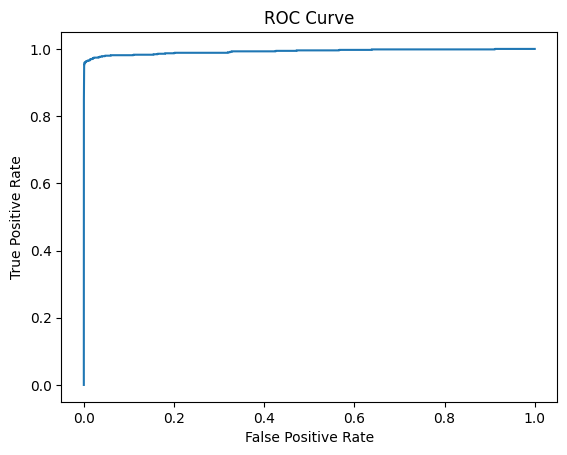

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

*   Visualizes classifier's performance across different thresholds, plotting True Positive Rate (TPR) against False Positive Rate (FPR).
*   A curve closer to the top-left corner indicates better model discrimination (high TPR, low FPR).
*   The Area Under the Curve (AUC) value quantifies overall performance; closer to 1 signifies a stronger model.

PCA Visualisation

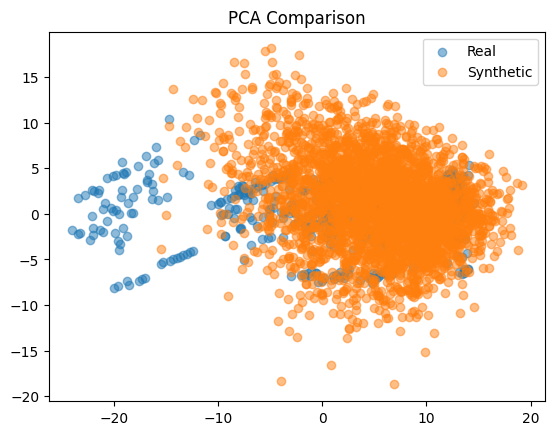

In [ ]:
real = df[df['Class']==1].drop(
    'Class',
    axis=1
)

synthetic = synthetic_fraud.drop(
    'Class',
    axis=1
)

pca = PCA(n_components=2)

real_pca = pca.fit_transform(real)

synthetic_pca = pca.transform(synthetic)

plt.scatter(
    real_pca[:,0],
    real_pca[:,1],
    label='Real',
    alpha=0.5
)

plt.scatter(
    synthetic_pca[:,0],
    synthetic_pca[:,1],
    label='Synthetic',
    alpha=0.5
)

plt.legend()

plt.title("PCA Comparison")

plt.show()

*   Compares the 2D distribution of real vs. synthetic fraudulent data.
*   Ideal synthetic data should largely overlap and mimic the distribution of real data.
*   Significant separation or unique clusters in synthetic data suggest the CTGAN model might not be generating high-fidelity samples, impacting data augmentation quality.

Save Model for Deployment

In [ ]:
joblib.dump(
    xgb,
    "fraud_model.pkl"
)

joblib.dump(
    list(top_features),
    "features.pkl"
)

['features.pkl']

Download Files

In [ ]:
from google.colab import files

files.download("fraud_model.pkl")

files.download("features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Conclusion**


* Developed a Credit Card Fraud Detection System using CTGAN and XGBoost.


* Solved class imbalance using synthetic fraud data generation with CTGAN.


* Selected top 5 important features to reduce model complexity.


* XGBoost achieved high accuracy, recall, F1-score, and ROC-AUC score.


* PCA visualization confirmed realistic synthetic fraud data generation.


* Deployed the model using Streamlit for real-time fraud prediction.


* Demonstrated effective use of Generative AI and Machine Learning in fraud detection.

